In [ ]:
import os
import pandas as pd

# Folder name where cluster csv files will be saved
output_folder = "sbert_clusters_csv"

# Create folder if not exists
os.makedirs(output_folder, exist_ok=True)

# Hardcoded cluster data
clusters = {
    
}

# Save each cluster into its own CSV file
for cluster_name, data in clusters.items():
    df = pd.DataFrame(data)
    file_path = os.path.join(output_folder, f"{cluster_name}.csv")
    df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

print("\nAll cluster CSV files created successfully!")


Saved: sbert_clusters_csv\Cluster_19.csv
Saved: sbert_clusters_csv\Cluster_20.csv
Saved: sbert_clusters_csv\Cluster_21.csv
Saved: sbert_clusters_csv\Cluster_22.csv
Saved: sbert_clusters_csv\Cluster_23.csv
Saved: sbert_clusters_csv\Cluster_24.csv
Saved: sbert_clusters_csv\Cluster_25.csv
Saved: sbert_clusters_csv\Cluster_26.csv
Saved: sbert_clusters_csv\Cluster_27.csv
Saved: sbert_clusters_csv\Cluster_28.csv
Saved: sbert_clusters_csv\Cluster_29.csv
Saved: sbert_clusters_csv\Cluster_30.csv

All cluster CSV files created successfully!


CALCULATING ARI SCORE FOR SBERT ONLY

In [2]:
import os
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# -----------------------------
# Paths
# -----------------------------
manual_file = "protocol_manual_classification_first2.csv"
sbert_cluster_folder = "sbert_clusters_csv"   # folder containing Cluster_1.csv, Cluster_2.csv etc.

# -----------------------------
# Load manual classification file
# -----------------------------
manual_df = pd.read_csv(manual_file)

manual_df.columns = manual_df.columns.str.strip()
manual_df["Word"] = manual_df["Word"].astype(str).str.strip().str.lower()
manual_df["REMARK"] = manual_df["REMARK"].astype(str).str.strip().str.lower()

# Convert manual remark clusters into numeric labels
manual_df["manual_cluster"] = manual_df["REMARK"].astype("category").cat.codes

# -----------------------------
# Load SBERT cluster CSV files and assign predicted cluster labels
# -----------------------------
predicted_cluster_map = {}

for filename in os.listdir(sbert_cluster_folder):
    if filename.endswith(".csv"):

        # Example filename: Cluster_6.csv
        cluster_id = int(filename.replace("Cluster_", "").replace(".csv", ""))

        file_path = os.path.join(sbert_cluster_folder, filename)
        df = pd.read_csv(file_path)

        df.columns = df.columns.str.strip()
        df["Word"] = df["Word"].astype(str).str.strip().str.lower()

        for word in df["Word"]:
            predicted_cluster_map[word] = cluster_id

# -----------------------------
# Map predicted cluster labels to manual words
# -----------------------------
manual_df["predicted_cluster"] = manual_df["Word"].map(predicted_cluster_map)

# Remove words that are not found in SBERT cluster folder
aligned_df = manual_df.dropna(subset=["predicted_cluster"]).copy()

aligned_df["predicted_cluster"] = aligned_df["predicted_cluster"].astype(int)

# -----------------------------
# Compute ARI score
# -----------------------------
ari_score = adjusted_rand_score(
    aligned_df["manual_cluster"],
    aligned_df["predicted_cluster"]
)

# -----------------------------
# Print results
# -----------------------------
print("========== ARI SCORE RESULTS ==========")
print("Adjusted Rand Index (ARI):", ari_score)
print("Total words in manual file:", len(manual_df))
print("Words matched with SBERT clusters:", len(aligned_df))
print("Words NOT found in SBERT clusters:", len(manual_df) - len(aligned_df))

# -----------------------------
# (Optional) Show unmatched words
# -----------------------------
unmatched_words = manual_df[manual_df["predicted_cluster"].isna()]["Word"].tolist()

print("\n========== UNMATCHED WORDS ==========")
print(unmatched_words)


========== ARI SCORE RESULTS ==========
Adjusted Rand Index (ARI): 0.3464316105778303
Total words in manual file: 270
Words matched with SBERT clusters: 270
Words NOT found in SBERT clusters: 0

========== UNMATCHED WORDS ==========
[]


CALCULATING ARI SCORE FOR ALL CLUSTERS RESULTS

In [4]:
import os
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# -----------------------------
# INPUT PATHS
# -----------------------------
manual_file = "protocol_manual_classification_first2.csv"
base_results_folder = "results cluster"   # main folder containing technique folders

# -----------------------------
# Load Manual Ground Truth
# -----------------------------
manual_df = pd.read_csv(manual_file)

manual_df.columns = manual_df.columns.str.strip()
manual_df["Word"] = manual_df["Word"].astype(str).str.strip().str.lower()
manual_df["REMARK"] = manual_df["REMARK"].astype(str).str.strip().str.lower()

# Convert manual remark labels into numeric cluster labels
manual_df["manual_cluster"] = manual_df["REMARK"].astype("category").cat.codes


# -----------------------------
# Function: Load predicted clusters from a folder
# -----------------------------
def load_predicted_clusters(cluster_folder_path):
    predicted_cluster_map = {}

    for filename in os.listdir(cluster_folder_path):
        if filename.endswith(".csv"):

            # Remove ".csv"
            name = filename.replace(".csv", "").strip().lower()

            # Now name can be like "cluster_1"
            if "cluster_" in name:
                cluster_id = int(name.replace("cluster_", ""))
            else:
                # If file name is unexpected, skip it
                print(f"Skipping file (unknown format): {filename}")
                continue

            file_path = os.path.join(cluster_folder_path, filename)
            df = pd.read_csv(file_path)

            df.columns = df.columns.str.strip()
            df["Word"] = df["Word"].astype(str).str.strip().str.lower()

            for word in df["Word"]:
                predicted_cluster_map[word] = cluster_id

    return predicted_cluster_map


# -----------------------------
# Compute ARI for each technique folder
# -----------------------------
results = []

for technique_folder in os.listdir(base_results_folder):
    technique_path = os.path.join(base_results_folder, technique_folder)

    if os.path.isdir(technique_path):

        predicted_cluster_map = load_predicted_clusters(technique_path)

        # Map predicted clusters to manual dataframe
        temp_df = manual_df.copy()
        temp_df["predicted_cluster"] = temp_df["Word"].map(predicted_cluster_map)

        # Keep only matched words
        aligned_df = temp_df.dropna(subset=["predicted_cluster"]).copy()
        aligned_df["predicted_cluster"] = aligned_df["predicted_cluster"].astype(int)

        # Compute ARI only if enough matches exist
        if len(aligned_df) > 1:
            ari_score = adjusted_rand_score(
                aligned_df["manual_cluster"],
                aligned_df["predicted_cluster"]
            )
        else:
            ari_score = None

        results.append({
            "Technique": technique_folder,
            "ARI_Score": ari_score,
            "Total_Manual_Words": len(temp_df),
            "Matched_Words": len(aligned_df),
            "Unmatched_Words": len(temp_df) - len(aligned_df)
        })

# -----------------------------
# Print Results
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="ARI_Score", ascending=False)

print("\n========== ARI SCORES FOR ALL TECHNIQUES ==========\n")
print(results_df.to_string(index=False))



========== ARI SCORES FOR ALL TECHNIQUES ==========

          Technique  ARI_Score  Total_Manual_Words  Matched_Words  Unmatched_Words
  cookbert_clusters   0.198038                 270            270                0
  foodbert_clusters   0.124571                 270            270                0
   biobert_clusters   0.117873                 270            270                0
pubmedbert_clusters   0.047711                 270            270                0
   doc2vec_clusters  -0.005900                 270            270                0


MAKING NEW MANUAL DATA

In [5]:
import pandas as pd

# -----------------------------
# Load original manual file
# -----------------------------
input_file = "protocol_manual_classification_first2.csv"
output_file = "protocol_manual_classification_updated.csv"

df = pd.read_csv(input_file)

df.columns = df.columns.str.strip()
df["Word"] = df["Word"].astype(str).str.strip().str.lower()
df["REMARK"] = df["REMARK"].astype(str).str.strip().str.lower()

# -----------------------------
# Word -> New Remark Mapping
# -----------------------------
remark_updates = {

    # circular/flip action cluster
    "invert": "circular/flip action",
    "twist": "circular/flip action",
    "swirl": "circular/flip action",
    "whirl": "circular/flip action",
    "turn": "circular/flip action",

    # resting / leaving food cluster
    "settle": "resting/leaving food",
    "repeat": "resting/leaving food",
    "stand": "resting/leaving food",
    "sit": "resting/leaving food",
    "wait": "resting/leaving food",
    "rest": "resting/leaving food",
    "set": "resting/leaving food",

    # noting cluster
    "note": "noting",

    # skin/opening action cluster
    "unmold": "skin/opening action",
    "strip": "skin/opening action",
    "unwrap": "skin/opening action",
    "skin": "skin/opening action",
    "peel": "skin/opening action",
    "open": "skin/opening action",

    # measuring/units cluster
    "dollop": "measuring/units",
    "ladle": "measuring/units",
    "measure": "measuring/units",
    "scoop": "measuring/units",

    # massage action cluster
    "pick": "massage action",
    "rub": "massage action",
    "pat": "massage action",
    "press": "massage action",
    "touch": "massage action",

    # starting/checking action cluster
    "stop": "starting/checking action",
    "rotate": "starting/checking action",
    "flip": "starting/checking action",
    "uncover": "starting/checking action",
    "uncovered": "starting/checking action",
    "test": "starting/checking action",
    "check": "starting/checking action",
    "start": "starting/checking action",
    "taste": "starting/checking action",

    # cooking sound cluster
    "splutter": "cooking sound",
    "foam": "cooking sound",
    "bubbling": "cooking sound",
    "sizzle": "cooking sound",
    "bubble": "cooking sound",

    # wrapping action cluster
    "frost": "wrapping action",
    "foil": "wrapping action",
    "wrap": "wrapping action",
    "cover": "wrapping action",

    # string/thread action cluster
    "thread": "string/thread action",
    "tie": "string/thread action"
}

# -----------------------------
# Apply updates
# -----------------------------
df["REMARK_UPDATED"] = df.apply(
    lambda row: remark_updates[row["Word"]] if row["Word"] in remark_updates else row["REMARK"],
    axis=1
)

# Replace REMARK column
df["REMARK"] = df["REMARK_UPDATED"]
df.drop(columns=["REMARK_UPDATED"], inplace=True)

# Save updated ground truth
df.to_csv(output_file, index=False)

print("Updated file saved as:", output_file)
print("Total updated words:", sum(df["Word"].isin(remark_updates.keys())))


Updated file saved as: protocol_manual_classification_updated.csv
Total updated words: 48


========== BASIC INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Word    270 non-null    object
 1   REMARK  270 non-null    object
dtypes: object(2)
memory usage: 4.3+ KB
None

========== SAMPLE ROWS ==========
        Word         REMARK
0   splutter  cooking sound
1    deflate   shape change
2     stream         action
3      crimp   shape change
4    floured         action
5      punch   shape change
6     devein       cleaning
7     select         action
8  sterilize       cleaning
9    overmix         mixing

========== UNIQUE CLUSTERS (REMARKS) ==========
Total unique remarks: 37

========== CLUSTER DISTRIBUTION ==========
REMARK
action                      39
shape change                34
cutting                     22
flavoring                   13
mixing                      13
more cooking                12
reduce water        

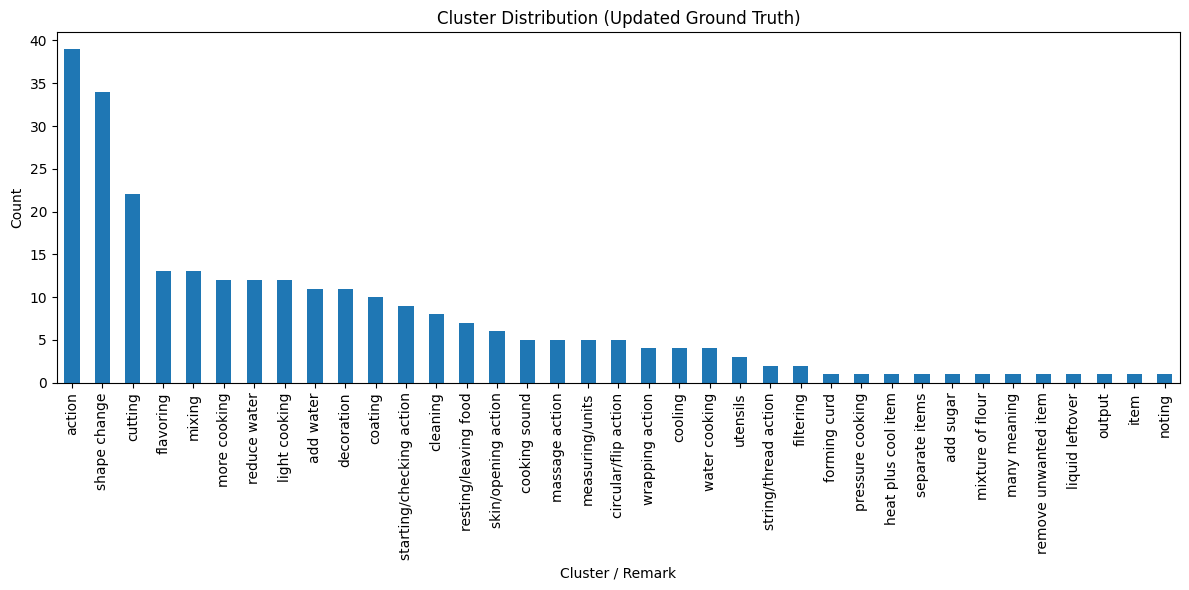


========== TOP 20 LARGEST CLUSTERS ==========
REMARK
action                      39
shape change                34
cutting                     22
flavoring                   13
mixing                      13
more cooking                12
reduce water                12
light cooking               12
add water                   11
decoration                  11
coating                     10
starting/checking action     9
cleaning                     8
resting/leaving food         7
skin/opening action          6
cooking sound                5
massage action               5
measuring/units              5
circular/flip action         5
wrapping action              4
Name: count, dtype: int64

========== CHECK DUPLICATE WORDS ==========
Duplicate word rows: 0
Empty DataFrame
Columns: [Word, REMARK]
Index: []

========== CHECK MISSING VALUES ==========
Word      0
REMARK    0
dtype: int64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

updated_file = "protocol_manual_classification_updated.csv"
df_new = pd.read_csv(updated_file)

df_new.columns = df_new.columns.str.strip()
df_new["Word"] = df_new["Word"].astype(str).str.strip().str.lower()
df_new["REMARK"] = df_new["REMARK"].astype(str).str.strip().str.lower()

print("========== BASIC INFO ==========")
print(df_new.info())

print("\n========== SAMPLE ROWS ==========")
print(df_new.head(10))

print("\n========== UNIQUE CLUSTERS (REMARKS) ==========")
print("Total unique remarks:", df_new["REMARK"].nunique())

print("\n========== CLUSTER DISTRIBUTION ==========")
remark_counts = df_new["REMARK"].value_counts()
print(remark_counts)

# Plot cluster distribution
plt.figure(figsize=(12,6))
remark_counts.plot(kind="bar")
plt.title("Cluster Distribution (Updated Ground Truth)")
plt.xlabel("Cluster / Remark")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\n========== TOP 20 LARGEST CLUSTERS ==========")
print(remark_counts.head(20))

print("\n========== CHECK DUPLICATE WORDS ==========")
duplicates = df_new[df_new.duplicated(subset=["Word"], keep=False)]
print("Duplicate word rows:", len(duplicates))
print(duplicates)

print("\n========== CHECK MISSING VALUES ==========")
print(df_new.isnull().sum())


In [8]:
import os
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# -----------------------------
# PATHS
# -----------------------------
manual_file = "protocol_manual_classification_updated.csv"

# SBERT cluster folder
sbert_cluster_folder = "sbert_clusters_csv"   # change name if needed

# Folder containing all other model clusters
base_results_folder = "results cluster"


# -----------------------------
# Load Updated Manual Ground Truth
# -----------------------------
manual_df = pd.read_csv(manual_file)

manual_df.columns = manual_df.columns.str.strip()
manual_df["Word"] = manual_df["Word"].astype(str).str.strip().str.lower()
manual_df["REMARK"] = manual_df["REMARK"].astype(str).str.strip().str.lower()

# Convert remark labels into numeric manual labels
manual_df["manual_cluster"] = manual_df["REMARK"].astype("category").cat.codes


# -----------------------------
# Function: Load predicted clusters from folder
# -----------------------------
def load_predicted_clusters(cluster_folder_path):
    predicted_cluster_map = {}

    for filename in os.listdir(cluster_folder_path):
        if filename.endswith(".csv"):

            name = filename.replace(".csv", "").strip().lower()

            # Supports: cluster_1.csv or Cluster_1.csv
            if "cluster_" in name:
                cluster_id = int(name.replace("cluster_", ""))
            else:
                print(f"Skipping file (unknown format): {filename}")
                continue

            file_path = os.path.join(cluster_folder_path, filename)
            df = pd.read_csv(file_path)

            df.columns = df.columns.str.strip()
            df["Word"] = df["Word"].astype(str).str.strip().str.lower()

            for word in df["Word"]:
                predicted_cluster_map[word] = cluster_id

    return predicted_cluster_map


# -----------------------------
# Function: Calculate ARI given a cluster folder
# -----------------------------
def calculate_ari(cluster_folder_path, technique_name):
    predicted_cluster_map = load_predicted_clusters(cluster_folder_path)

    temp_df = manual_df.copy()
    temp_df["predicted_cluster"] = temp_df["Word"].map(predicted_cluster_map)

    aligned_df = temp_df.dropna(subset=["predicted_cluster"]).copy()
    aligned_df["predicted_cluster"] = aligned_df["predicted_cluster"].astype(int)

    ari_score = adjusted_rand_score(
        aligned_df["manual_cluster"],
        aligned_df["predicted_cluster"]
    )

    return {
        "Technique": technique_name,
        "ARI_Score": ari_score,
        "Total_Manual_Words": len(temp_df),
        "Matched_Words": len(aligned_df),
        "Unmatched_Words": len(temp_df) - len(aligned_df)
    }


# -----------------------------
# Compute ARI for SBERT + All Techniques
# -----------------------------
results = []

# SBERT ARI
results.append(calculate_ari(sbert_cluster_folder, "sbert_clusters"))

# Other models ARI
for technique_folder in os.listdir(base_results_folder):
    technique_path = os.path.join(base_results_folder, technique_folder)

    if os.path.isdir(technique_path):
        results.append(calculate_ari(technique_path, technique_folder))


# -----------------------------
# Print results
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="ARI_Score", ascending=False)

print("\n========== UPDATED GROUND TRUTH ARI SCORES (ALL MODELS + SBERT) ==========\n")
print(results_df.to_string(index=False))


# -----------------------------
# Save results
# -----------------------------
results_df.to_csv("ARI_results_updated_groundtruth_all_models.csv", index=False)
print("\nSaved results to: ARI_results_updated_groundtruth_all_models.csv")



========== UPDATED GROUND TRUTH ARI SCORES (ALL MODELS + SBERT) ==========

          Technique  ARI_Score  Total_Manual_Words  Matched_Words  Unmatched_Words
     sbert_clusters   0.536002                 270            270                0
  cookbert_clusters   0.280984                 270            270                0
   biobert_clusters   0.167759                 270            270                0
  foodbert_clusters   0.155018                 270            270                0
pubmedbert_clusters   0.068559                 270            270                0
   doc2vec_clusters  -0.003620                 270            270                0

Saved results to: ARI_results_updated_groundtruth_all_models.csv


In [1]:
import os
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# ============================================
# ARI SCORES FOR RECIPEBERT CLUSTERS
# ============================================

# Paths
recipebert_clusters_folder = "results cluster/recipebert_clusters"
manual_file_first2 = "protocol_manual_classification_first2.csv"
manual_file_updated = "protocol_manual_classification_updated.csv"

# Function to load predicted clusters
def load_predicted_clusters(cluster_folder_path):
    predicted_cluster_map = {}
    
    for filename in os.listdir(cluster_folder_path):
        if filename.endswith(".csv"):
            name = filename.replace(".csv", "").strip().lower()
            
            if "cluster_" in name:
                cluster_id = int(name.replace("cluster_", ""))
            else:
                print(f"Skipping file (unknown format): {filename}")
                continue
            
            file_path = os.path.join(cluster_folder_path, filename)
            df = pd.read_csv(file_path)
            
            df.columns = df.columns.str.strip()
            df["Word"] = df["Word"].astype(str).str.strip().str.lower()
            
            for word in df["Word"]:
                predicted_cluster_map[word] = cluster_id
    
    return predicted_cluster_map

# Function to calculate ARI
def calculate_ari_score(manual_file, recipebert_clusters_folder, ground_truth_name):
    # Load manual file
    manual_df = pd.read_csv(manual_file)
    manual_df.columns = manual_df.columns.str.strip()
    manual_df["Word"] = manual_df["Word"].astype(str).str.strip().str.lower()
    manual_df["REMARK"] = manual_df["REMARK"].astype(str).str.strip().str.lower()
    
    # Convert remark to numeric labels
    manual_df["manual_cluster"] = manual_df["REMARK"].astype("category").cat.codes
    
    # Load RecipeBERT clusters
    predicted_cluster_map = load_predicted_clusters(recipebert_clusters_folder)
    
    # Map predicted clusters
    manual_df["predicted_cluster"] = manual_df["Word"].map(predicted_cluster_map)
    
    # Keep only matched words
    aligned_df = manual_df.dropna(subset=["predicted_cluster"]).copy()
    aligned_df["predicted_cluster"] = aligned_df["predicted_cluster"].astype(int)
    
    # Calculate ARI
    ari_score = adjusted_rand_score(
        aligned_df["manual_cluster"],
        aligned_df["predicted_cluster"]
    )
    
    return {
        "Ground_Truth": ground_truth_name,
        "ARI_Score": ari_score,
        "Total_Manual_Words": len(manual_df),
        "Matched_Words": len(aligned_df),
        "Unmatched_Words": len(manual_df) - len(aligned_df),
        "Match_Percentage": f"{(len(aligned_df) / len(manual_df) * 100):.2f}%"
    }

# Calculate for both ground truth files
print("\n" + "="*60)
print("ARI SCORES FOR RECIPEBERT CLUSTERS")
print("="*60)

results = []

# Check if folder exists
if os.path.isdir(recipebert_clusters_folder):
    result_first2 = calculate_ari_score(
        manual_file_first2, 
        recipebert_clusters_folder, 
        "protocol_manual_classification_first2"
    )
    results.append(result_first2)
    
    result_updated = calculate_ari_score(
        manual_file_updated, 
        recipebert_clusters_folder, 
        "protocol_manual_classification_updated"
    )
    results.append(result_updated)
    
    # Print results
    results_df = pd.DataFrame(results)
    print("\n", results_df.to_string(index=False))
    
    # Save results
    results_df.to_csv("recipebert_ari_scores.csv", index=False)
    print("\n✅ Results saved to: recipebert_ari_scores.csv")
    
else:
    print(f"❌ Folder not found: {recipebert_clusters_folder}")
    print("\nAvailable folders in 'results cluster':")
    if os.path.isdir("results cluster"):
        for folder in os.listdir("results cluster"):
            if os.path.isdir(os.path.join("results cluster", folder)):
                print(f"  - {folder}")



ARI SCORES FOR RECIPEBERT CLUSTERS

                           Ground_Truth  ARI_Score  Total_Manual_Words  Matched_Words  Unmatched_Words Match_Percentage
 protocol_manual_classification_first2   0.124571                 270            270                0          100.00%
protocol_manual_classification_updated   0.155018                 270            270                0          100.00%

✅ Results saved to: recipebert_ari_scores.csv


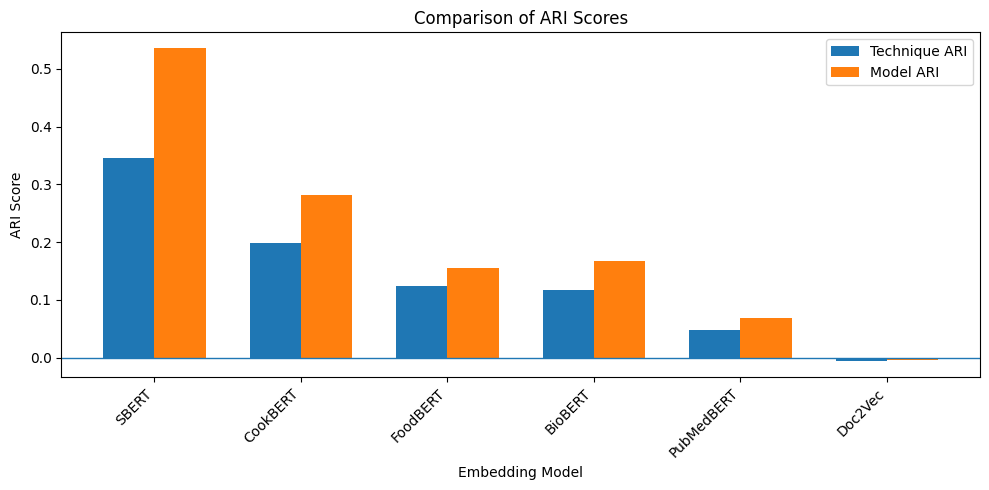

In [1]:
import matplotlib.pyplot as plt

labels = ["SBERT", "CookBERT", "FoodBERT", "BioBERT", "PubMedBERT", "Doc2Vec"]

ari_set_1 = [0.346432, 0.198038, 0.124571, 0.117873, 0.047711, -0.005900]
ari_set_2 = [0.5360, 0.2810, 0.1550, 0.1678, 0.0686, -0.0036]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], ari_set_1, width=width, label="Technique ARI")
plt.bar([i + width/2 for i in x], ari_set_2, width=width, label="Model ARI")

plt.axhline(0, linewidth=1)
plt.title("Comparison of ARI Scores")
plt.xlabel("Embedding Model")
plt.ylabel("ARI Score")
plt.xticks(list(x), labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()